In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Dados completos.csv',sep=';')
df = df.drop(columns=['Unnamed: 7','Unnamed: 8'])

colunas_texto = df.select_dtypes(include=['object', 'string']).columns

for coluna in colunas_texto:
    df[coluna] = df[coluna].str.replace('.', '', regex=False).astype(float)

In [12]:
display(df.head())
display(df.info())

,Média,Variância,Máximo,Energia,Skewness,Kurtosis,Label
0,-8.118985e+15,5.046065e+15,4.260445e+15,1.953800e+16,-1.530590e+15,8.882906e+15,1
1,-7.001265e+15,2.914391e+16,3.199970e+15,1.132615e+16,-1.704711e+15,5.186916e+15,1
2,-8.304564e+15,4.730422e+15,4.120398e+15,1.834326e+15,6.256202e+14,6.203662e+15,1
3,-6.039109e+15,3.363005e+15,3.598051e+15,1.299280e+16,5.076175e+15,7.962693e+14,1
4,-4.586327e+15,2.934315e+16,3.229173e+15,1.129535e+16,7.629875e+15,6.374970e+15,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Média      1000 non-null   float64
 1   Variância  1000 non-null   float64
 2   Máximo     1000 non-null   float64
 3   Energia    1000 non-null   float64
 4   Skewness   1000 non-null   float64
 5   Kurtosis   1000 non-null   float64
 6   Label      1000 non-null   int64  
dtypes: float64(6), int64(1)
memory usage: 54.8 KB


None

In [13]:
df_com_cilindro = df[df['Label']==1]
df_sem_cilindro = df[df['Label']==0]

display(df_com_cilindro.describe())
display(df_sem_cilindro.describe())

,Média,Variância,Máximo,Energia,Skewness,Kurtosis,Label
count,5.030000e+02,5.030000e+02,5.030000e+02,5.030000e+02,5.030000e+02,5.030000e+02,503.0
mean,-9.128658e+15,1.186117e+16,7.889120e+15,1.075886e+16,-1.713036e+15,9.872247e+15,1.0
std,1.174662e+16,1.335260e+16,1.126990e+16,7.820687e+15,5.749948e+15,1.376277e+16,0.0
min,-7.864163e+16,2.548662e+13,2.052793e+11,1.151178e+13,-2.459727e+16,4.244220e+13,1.0
25%,-8.680478e+15,3.087697e+15,2.884835e+15,5.569425e+15,-4.659830e+15,4.482213e+15,1.0
50%,-7.259698e+15,4.358536e+15,3.385219e+15,1.122848e+16,-9.995650e+14,6.086920e+15,1.0
75%,-5.619439e+15,2.276837e+16,4.169477e+15,1.470460e+16,1.463974e+15,7.828531e+15,1.0
max,-6.145350e+13,7.123235e+16,4.723585e+16,6.685438e+16,1.797384e+16,7.895620e+16,1.0


,Média,Variância,Máximo,Energia,Skewness,Kurtosis,Label
count,4.970000e+02,4.970000e+02,4.970000e+02,4.970000e+02,4.970000e+02,4.970000e+02,497.0
mean,-7.739079e+15,1.160442e+16,7.793935e+15,9.776072e+15,-1.192084e+16,9.204697e+15,0.0
std,6.531259e+15,9.365508e+15,1.079970e+16,1.246755e+16,1.072581e+16,9.781553e+15,0.0
min,-7.853442e+16,2.480999e+12,2.936875e+06,6.999357e+12,-3.899531e+16,5.917117e+13,0.0
25%,-9.814453e+15,2.163459e+15,2.853061e+15,5.581683e+15,-2.055532e+16,4.662441e+15,0.0
50%,-8.724650e+15,1.343948e+16,3.397258e+15,7.321101e+15,-9.750320e+15,8.103275e+15,0.0
75%,-7.027818e+15,1.843340e+16,4.177461e+15,9.306147e+15,-2.327549e+15,1.127041e+16,0.0
max,-9.296770e+12,6.258748e+16,4.724941e+16,6.686140e+16,-1.814993e+13,7.446754e+16,0.0


,Label,Skewness
0,0,-1.192084e+16
1,1,-1.713036e+15


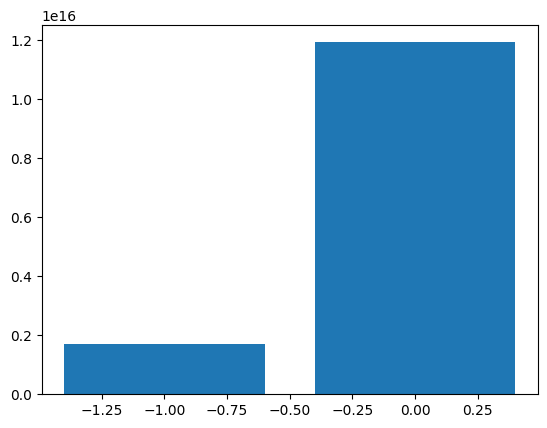

In [14]:
df_skew = df[['Skewness','Label']].groupby('Label',as_index=False).mean()
display(df_skew)

plt.figure()
plt.bar(x=-df_skew['Label'],height=-df_skew['Skewness'])
plt.show()


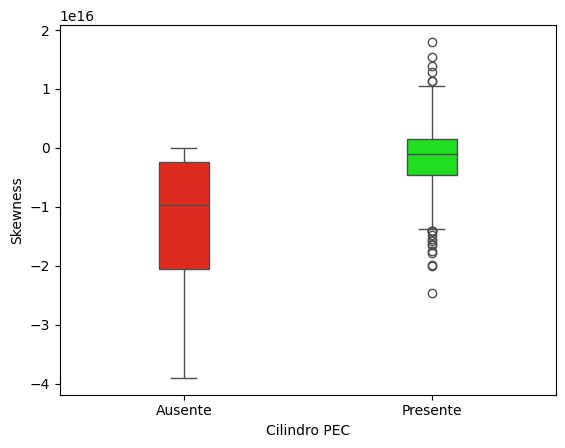

In [15]:
plt.figure()
#plt.boxplot(x=[df_sem_cilindro['Skewness'],df_com_cilindro['Skewness']])
sns.boxplot(data=df, x='Label', y='Skewness',hue='Label',palette=["#FF0D00", "#00FF00"],legend=False,width=0.2,dodge=False)
plt.xticks((0,1),('Ausente','Presente'))
plt.xlabel('Cilindro PEC')
plt.ylabel('Skewness')
plt.show()

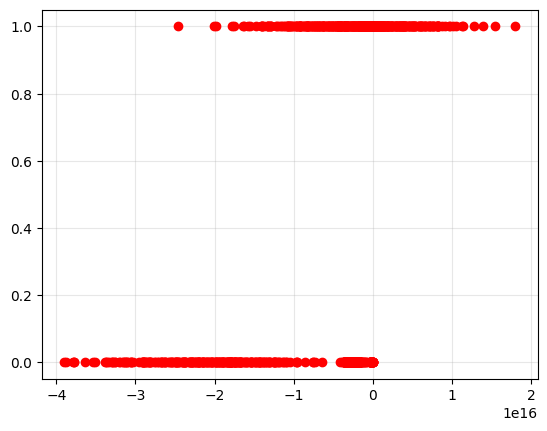

In [16]:
plt.figure()
plt.grid(alpha=0.3)
plt.plot(df['Skewness'],df['Label'],'o',color='red')
plt.show()

,Label,Energia
0,0,9.776072e+15
1,1,1.075886e+16


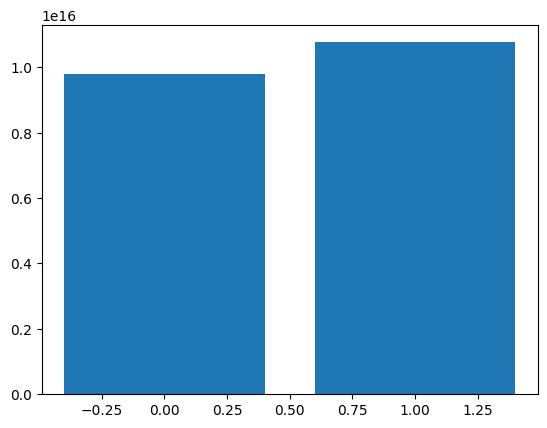

In [17]:
df_energia = df[['Energia','Label']].groupby('Label',as_index=False).mean()
display(df_energia)

plt.figure()
plt.bar(x=df_energia['Label'],height=df_energia['Energia'])
plt.show()

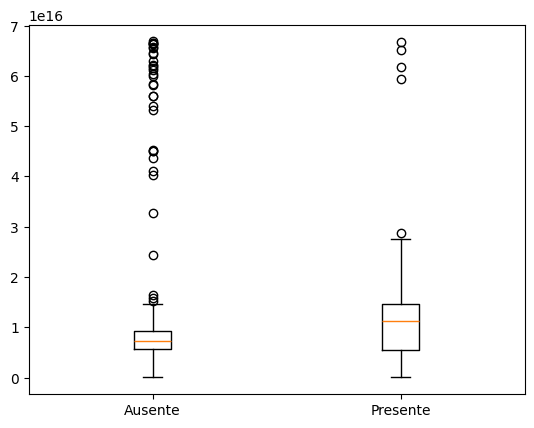

In [18]:
plt.figure()
plt.boxplot(x=[df_sem_cilindro['Energia'],df_com_cilindro['Energia']])
plt.xticks((1,2),('Ausente','Presente'))
plt.show()